In [1]:
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import scipy.misc as misc
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
from sklearn.datasets import load_sample_image
from sklearn.utils import shuffle
from time import time
from PIL import Image
from IPython.display import Image
import six
from io import StringIO
from sklearn import cluster
import imageio

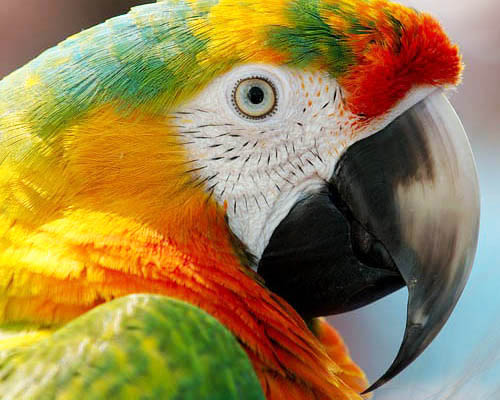

In [2]:
# 6b) Exibição da Imagem
Image(filename='img2.jpg') 

In [3]:
# 6a) Carrega a imagem e verifica as dimensões da array carregada.
filename="img2.jpg"

#To load the image as an numpy array
#Carrega a Imagem
image = imageio.imread(filename)

#Dimensões da Array carregada
print('Array carregada da imagem original:\n')
print(image)

#Dimenões da imagem
print('\nDimensões da imagem Original(LxAxP):', image.shape)

Array carregada da imagem original:

[[[175 131 118]
  [175 131 118]
  [174 130 117]
  ...
  [201 180 177]
  [200 179 176]
  [199 178 175]]

 [[175 131 118]
  [175 131 118]
  [174 130 117]
  ...
  [200 179 176]
  [199 178 175]
  [199 178 175]]

 [[174 130 117]
  [174 130 117]
  [174 130 117]
  ...
  [199 178 175]
  [198 177 174]
  [198 177 174]]

 ...

 [[191 187 100]
  [201 196 114]
  [215 211 137]
  ...
  [166 185 192]
  [166 185 192]
  [166 185 192]]

 [[191 193 110]
  [203 206 127]
  [219 220 150]
  ...
  [165 184 191]
  [165 184 191]
  [165 184 191]]

 [[195 203 120]
  [208 215 138]
  [223 228 161]
  ...
  [164 183 190]
  [164 183 190]
  [164 183 190]]]

Dimensões da imagem Original(LxAxP): (400, 500, 3)


In [4]:
n_colors = 64 # Value of K is the data points (seeds) to be the initial centroids

image2d = np.array(image, dtype=np.float64) / 255

# Load Image and transform to a 2D numpy array.
w, h, d = original_shape = tuple(image.shape)

assert d == 3

In [5]:
# 6c) Array carregada em 2D

image_array2d = np.reshape(image2d, (w * h, d))
print('Array carregada em 2D:\n')
print(image_array2d)
print('\nDimensões da imagem 2D(LxA,P):', image_array2d.shape)

Array carregada em 2D:

[[0.68627451 0.51372549 0.4627451 ]
 [0.68627451 0.51372549 0.4627451 ]
 [0.68235294 0.50980392 0.45882353]
 ...
 [0.64313725 0.71764706 0.74509804]
 [0.64313725 0.71764706 0.74509804]
 [0.64313725 0.71764706 0.74509804]]

Dimensões da imagem 2D(LxA,P): (200000, 3)


## Treinando Clusters com K-means

In [6]:
def quantize(image, n_colors):
    width, height, depth = image.shape
    reshaped_image = np.reshape(image2d, (width * height, depth))
    
    t0 = time()
    image_array_sample = shuffle(reshaped_image, random_state=0)[:1000]
    
    # 6D) Treinamento dos 4 clusterizadores k-Means
    image_array_model = cluster.KMeans(n_clusters=n_colors, random_state=0).fit(image_array_sample)
    
    # 6E) Predição dos clusterizadores k-Means
    labels = image_array_model.predict(reshaped_image)
    
    # 6F) atribua a cada pixel da imagem original o valor do centroide do cluster mais próximo
    palette = image_array_model.cluster_centers_

    quantized_image = np.reshape(palette[labels], (width, height, palette.shape[1]))
    print('Dimensões da imagem 2D(LxA,P):', reshaped_image.shape)

    return quantized_image

## Exibição das imagens quantizadas para cada um dos 4 clusters

Dimensões da imagem 2D(LxA,P): (200000, 3)


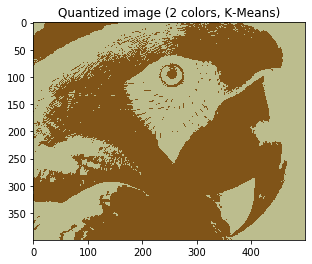

In [7]:
# 6G)Exibição da imagem quantizada para n_colors= 2

plt.title('Quantized image (2 colors, K-Means)')
plt.imshow(quantize(image, 2))

Dimensões da imagem 2D(LxA,P): (200000, 3)


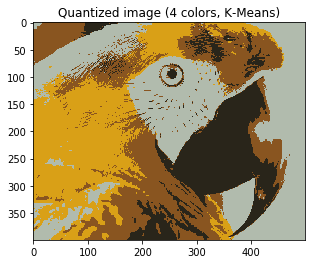

In [8]:
# 6G)Exibição da imagem quantizada para n_colors= 4

plt.title('Quantized image (4 colors, K-Means)')
plt.imshow(quantize(image, 4))

Dimensões da imagem 2D(LxA,P): (200000, 3)


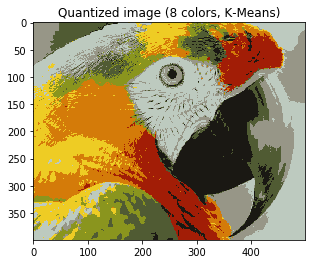

In [9]:
# 6G)Exibição da imagem quantizada para n_colors= 8

plt.title('Quantized image (8 colors, K-Means)')
plt.imshow(quantize(image, 8))

Dimensões da imagem 2D(LxA,P): (200000, 3)


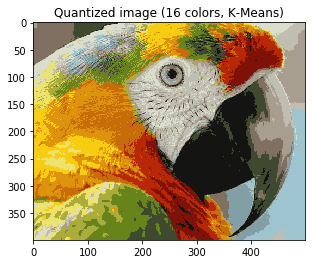

In [10]:
# 6G)Exibição da imagem quantizada para n_colors= 16

plt.title('Quantized image (16 colors, K-Means)')
plt.imshow(quantize(image, 16))

**6H.) Se cada uma das 3 cores do RGB é representada por 1 byte (i.e., 8 bits) qual o
tamanho aproximado da imagem original e de cada uma das 4 imagens
quantizadas?**
Resposta:  

In [11]:
w= 500
h = 400

bit_depth = 8

tamanho_imagem = (w* h * (bit_depth/8) * 3)

print('Tamanho da imagem Original é:', tamanho_imagem, 'Bytes')


bit_depth = 1

tamanho_imagem = (w* h * (bit_depth/8) * 3)
print('Tamanho da imagem Com duas cores é:', tamanho_imagem, 'Bytes')

bit_depth = 2

tamanho_imagem = (w* h * (bit_depth/8) * 3)
print('Tamanho da imagem Com quatro cores é:', tamanho_imagem, 'Bytes')


bit_depth = 3


tamanho_imagem = (w* h * (bit_depth/8) * 3)
print('Tamanho da imagem Com oito cores é:', tamanho_imagem, 'Bytes')

bit_depth = 4


tamanho_imagem = (w* h * (bit_depth/8) * 3)

print('Tamanho da imagem Com 16 cores é:', tamanho_imagem, 'Bytes')

Tamanho da imagem Original é: 600000.0 Bytes
Tamanho da imagem Com duas cores é: 75000.0 Bytes
Tamanho da imagem Com quatro cores é: 150000.0 Bytes
Tamanho da imagem Com oito cores é: 225000.0 Bytes
Tamanho da imagem Com 16 cores é: 300000.0 Bytes
